<a href="https://colab.research.google.com/github/mardemes/paper-hel-jasmim-TGD-/blob/main/Paper_Hel_Jas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# BLOCO 1: AUTENTICAÇÃO E DOWNLOAD DO DATASET
# ==============================================================================
import os
import kagglehub
#https://www.kaggle.com/datasets/alexanderuzhinskiy/the-doctorp-project-dataset
# Configuração das credenciais do Kaggle
os.environ['KAGGLE_USERNAME'] = "jasmimleitemuniz"
os.environ['KAGGLE_KEY'] = "KGAT_21581036ec26aa3d8a3d7588112485b1"
print("Credenciais configuradas!")

# Download automático da versão mais recente do dataset
path = kagglehub.dataset_download("alexanderuzhinskiy/the-doctorp-project-dataset")
print("Path to dataset files:", path)

# Definição do caminho final das imagens
caminho_final = f"{path}/DoctorP_dataset"
print("Classes encontradas no dataset:\n", os.listdir(caminho_final))

# ==============================================================================
# BLOCO 2: CARREGAMENTO, DIVISÃO E OTIMIZAÇÃO DOS DATASETS (TENSORFLOW)
# ==============================================================================
import tensorflow as tf

# Criação do pipeline de treinamento (80% dos dados)
train_ds = tf.keras.utils.image_dataset_from_directory(
    caminho_final,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

# Guardar os nomes originais das 68 classes
class_names = train_ds.class_names

# Criação do pipeline de validação (20% dos dados remanescentes)
validation_ds = tf.keras.utils.image_dataset_from_directory(
    caminho_final,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

print(f"\nNúmero total de classes mapeadas: {len(class_names)}")

# Otimização de I/O em memória para acelerar as épocas de treino
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Aplicação da camada de pré-processamento nativa do MobileNetV2
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
train_ds_preprocessed = train_ds.map(lambda x, y: (preprocess_input(x), y))
validation_ds_preprocessed = validation_ds.map(lambda x, y: (preprocess_input(x), y))

print("Datasets carregados, normalizados e otimizados com sucesso!")

# ==============================================================================
# BLOCO 3: ARQUITETURA DO MODELO (TRANSFER LEARNING DE DOIS ESTÁGIOS)
# ==============================================================================
IMG_SHAPE = (224, 224, 3)

# Instanciação da rede MobileNetV2 pré-treinada na ImageNet (sem o topo original)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Camadas customizadas de pooling e classificação
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(len(class_names), activation='softmax')

# Construção da topologia sequencial do modelo final
model = tf.keras.Sequential([
    base_model,
    global_average_layer,
    prediction_layer
])

# ==============================================================================
# BLOCO 4: CONFIGURAÇÃO DE CALLBACKS E METODOLOGIA CIENTÍFICA DE TREINO
# ==============================================================================
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks dinâmicos para controle de convergência e prevenção de Overfitting
callbacks_lista = [
    # Interrompe o treino se a perda de validação parar de melhorar por 8 épocas seguidas
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Salva de forma persistente apenas o arquivo com o menor erro de validação
    ModelCheckpoint(
        filepath='melhor_modelo_plantas.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Reduz dinamicamente o Learning Rate caso o aprendizado estagne por 3 épocas
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ------------------------------------------------------------------------------
# FASE 1: Aquecimento do Classificador Customizado (Base Congelada)
# ------------------------------------------------------------------------------
print("\n[INFO] Iniciando Fase 1: Ajustando o topo de classificação (Base Congelada)...")
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

history_fase1 = model.fit(
    train_ds_preprocessed,
    epochs=15,
    validation_data=validation_ds_preprocessed,
    callbacks=callbacks_lista
)

# ------------------------------------------------------------------------------
# FASE 2: Fine-Tuning Avançado (Base Descongelada + Learning Rate Cirúrgico)
# ------------------------------------------------------------------------------
print("\n[INFO] Iniciando Fase 2: Descongelando pesos para Fine-Tuning completo...")
base_model.trainable = True

# Importante: Learning Rate extremamente baixo para não destruir os pesos da ImageNet
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Treinamento estendido protegido por EarlyStopping
history_fase2 = model.fit(
    train_ds_preprocessed,
    epochs=80,
    validation_data=validation_ds_preprocessed,
    callbacks=callbacks_lista
)

print("\nProcesso de treinamento em dois estágios concluído!")

# ==============================================================================
# BLOCO 5: MAPEAMENTOS E SISTEMA EXPERISTA DE RECOMENDAÇÃO
# ==============================================================================
# Dicionário robusto estruturado por Planta -> Doença/Condição -> Solução Agronômica
conhecimento_plantas_atualizado = {
    'Orquídea': {
        'Podridão Negra': 'Corte as partes afetadas com lâmina esterilizada e aplique canela em pó ou fungicida.',
        'Cochonilha': 'Remova manualmente com algodão embebido em álcool isopropílico ou use óleo de neem.',
        'Healthy': 'Mantenha as condições ideais de luz, umidade e nutrição. Faça regas regulares e verifique por pragas semanalmente.'
    },
    'Samambaia': {
        'Queima por Vento': 'Mude a planta para um local protegido de correntes de ar e aumente a umidade ambiente.',
        'Antracnose': 'Remova as frondes (folhas) infectadas e evite molhar as folhas ao regar.',
        'Healthy': 'Garanta boa umidade, sombra e solo bem drenado para a samambaia. Remova folhas secas regularmente.'
    },
    'Suculenta': {
        'Apodrecimento radicular': 'Reduza a frequência de regas e certifique-se de que o vaso tenha drenagem eficiente.',
        'Etiolamento': 'A planta está esticada por falta de luz. Mova-a gradualmente para um local com mais sol direto.',
        'Healthy': 'Forneça muita luz solar, solo bem drenado e regue moderadamente, deixando o solo secar entre as regas.'
    },
    'Antúrio': {
        'Clorose': 'Verifique se há excesso de luz direta ou falta de nutrientes. Aplique fertilizante rico em micronutrientes.',
        'Ácaros': 'Aumente a umidade e limpe as folhas com um pano úmido para remover as teias e ovos.',
        'Healthy': 'Mantenha em local com luz indireta brilhante e alta umidade. Regue quando o topo do solo estiver seco ao toque.'
    },
    'Generic_Disease': {
        'Black spots': 'Aplique fungicida sistêmico e melhore a circulação do ar ao redor da planta.',
        'Rust': 'Remova folhas infectadas e use um fungicida à base de cobre.',
        'Yellow leaves': 'Verifique excesso ou falta de água, deficiência nutricional ou estresse. Ajuste a rotina de cuidado.'
    }
}

# Mapeamento estático automatizado baseado nas 68 classes possíveis do modelo
mapeamento_classe_para_plantas = {classe: 'Generic' for classe in class_names}
# Customizações para espécies específicas encontradas nas classes do seu dataset:
mapeamento_classe_para_plantas['Cherry leaf spot'] = 'Cherry'
mapeamento_classe_para_plantas['Corn downy mildew'] = 'Corn'
mapeamento_classe_para_plantas['Pear blister mite'] = 'Pear'

print("Mapeamentos de conhecimento integrados.")

# ==============================================================================
# BLOCO 6: INTERFACE INTERATIVA COM GRADIO (SISTEMA ESPECIALISTA EM AGRO)
# ==============================================================================
import gradio as gr
from PIL import Image
import numpy as np

def predict_and_recommend(image: Image.Image):
    # Tratamento e redimensionamento da imagem de entrada vinda da interface
    img_array = np.array(image.resize((224, 224)))
    input_image_for_prediction = np.expand_dims(img_array, axis=0)
    preprocessed_input_image = preprocess_input(input_image_for_prediction)

    # Execução da inferência na rede treinada
    predictions = model.predict(preprocessed_input_image)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(predictions[0])

    # Inferência do tipo de espécie e resolução de chaves
    planta_identificada = mapeamento_classe_para_plantas.get(predicted_class_name, 'Generic')
    condicao_predita = predicted_class_name

    # Lógica fallback de busca no dicionário estruturado
    recomendacao = "Recomendação não encontrada para esta combinação de planta e diagnóstico."

    if planta_identificada != 'Generic' and planta_identificada in conhecimento_plantas_atualizado:
        if condicao_predita in conhecimento_plantas_atualizado[planta_identificada]:
            recomendacao = conhecimento_plantas_atualizado[planta_identificada][condicao_predita]
        else:
            if condicao_predita in conhecimento_plantas_atualizado.get('Generic_Disease', {}):
                recomendacao = conhecimento_plantas_atualizado['Generic_Disease'][condicao_predita]
    elif condicao_predita in conhecimento_plantas_atualizado.get('Generic_Disease', {}):
        recomendacao = conhecimento_plantas_atualizado['Generic_Disease'][condicao_predita]

    # Tratamento específico para casos saudáveis indeterminados
    if condicao_predita == 'Healthy' and "não encontrada" in recomendacao:
        for p in conhecimento_plantas_atualizado:
            if 'Healthy' in conhecimento_plantas_atualizado[p]:
                recomendacao = conhecimento_plantas_atualizado[p]['Healthy']
                break

    return (
        f"Diagnóstico: {predicted_class_name} (Confiança: {confidence * 100:.2f}%)",
        f"Espécie Alvo Inferida: {planta_identificada}",
        f"Ação Corretiva Recomendada:\n{recomendacao}"
    )

# Renderização do painel web para testes locais e compartilhados
iface = gr.Interface(
    fn=predict_and_recommend,
    inputs=gr.Image(type="pil", label="Carregar Foto da Folha Ornamentada"),
    outputs=[
        gr.Textbox(label="Laudo do Modelo Preditivo"),
        gr.Textbox(label="Classe Taxonômica Inferida"),
        gr.Textbox(label="Tratamento Agronômico"),
    ],
    title="Plataforma de Diagnóstico Inteligente de Plantas Ornamentais",
    description="Carregue uma amostra visual para correlacionar distúrbios patológicos foliares com protocolos de intervenções agronômicas."
)

# Executa a aplicação web (share=True gera link externo temporário no Colab)
iface.launch(debug=False, share=True)

Credenciais configuradas!


100%|██████████| 30.4M/30.4M [00:00<00:00, 75.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alexanderuzhinskiy/the-doctorp-project-dataset/versions/1
Classes encontradas no dataset:
 ['Thrips', 'Cherry leaf spot', 'Slugs', 'Mechanical damage', 'Leaf miners', 'Blossom end rot', 'Ants', 'Anthracnose', 'Lichen', 'Black spots', 'Bacterial spot', 'Esca', 'Aphid', 'Dry rot', 'Grey mold', 'Colorado beetle', 'Shot hole', 'Ascochyta blight', 'Alternaria leaf blight', 'Sooty mold', 'Pest damage', 'Leaf deformation', 'Frost cracks', 'Wilting', 'Mealybug', 'Mosaic virus', 'Tubercular necrosis', 'Powdery mildew', 'Leaves scorch', 'Gryllotalpa effects', 'Downy mildew', 'Shute', 'Loss of foliage turgor', 'Leaf spot', 'Black chaff', 'Edema', 'Northern leaf blight', 'Aphid effects', 'Wireworm', 'Corn downy mildew', 'Colorado beetle effects', 'Burn', 'Eyespot', 'Anthocyanosis', 'Monilia', 'Spider mite', 'Botrytis cinerea', 'Wireworm effects', 'Cyclamen mite', 'Galls', 'Marginal leaf necrosis', 'Gryllotalpa', 'Rust', 'Polypore', 'Canker', '

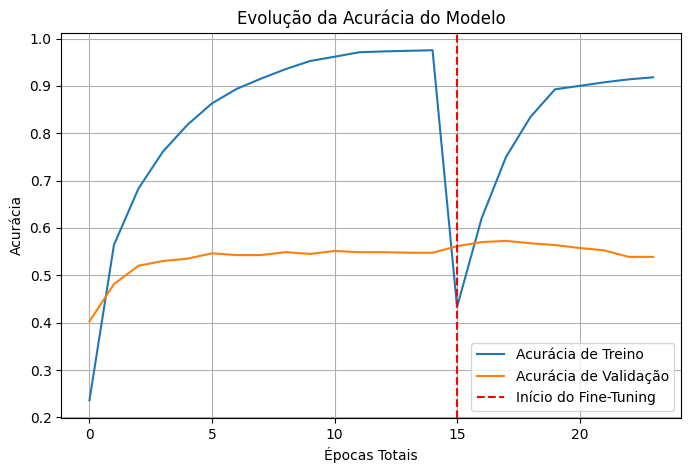

In [ ]:
import matplotlib.pyplot as plt

# Combinando históricos
acc = history_fase1.history['accuracy'] + history_fase2.history['accuracy']
val_acc = history_fase1.history['val_accuracy'] + history_fase2.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(acc, label='Acurácia de Treino')
plt.plot(val_acc, label='Acurácia de Validação')
plt.axvline(x=len(history_fase1.history['accuracy']), color='r', linestyle='--', label='Início do Fine-Tuning')
plt.title('Evolução da Acurácia do Modelo')
plt.xlabel('Épocas Totais')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()